# Synthetic vs. Real Rainfall: Comprehensive Comparison
This notebook provides a thorough data mining and statistical analysis to validate the fidelity of the generated synthetic rainfall data against the original training dataset.

### Analysis Dimensions:
1. **Distributional Fidelity:** Do the intensities match (Mean, Std, Quantiles)?
2. **Sparsity & Intermittency:** Is the dry-wet balance preserved?
3. **Temporal Dynamics:** Are the storm durations and return periods realistic?
4. **Extreme Events:** Does the model capture the heavy-tail distribution of high-intensity rain?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = [12, 6]

# Paths
REAL_PATH = '../data/rainfall/train/rainfall_10min.csv'
SYNTH_PATH = '../results/generated_data/rainfall_synthetic_10.0y_077efccb-d83d-4259-b120-6c04544f8fe0.csv'

# Load Data
df_real = pd.read_csv(REAL_PATH)
df_real['date'] = pd.to_datetime(df_real['date'])
df_real.set_index('date', inplace=True)

df_synth = pd.read_csv(SYNTH_PATH)
df_synth.loc[df_synth['avg_rainfall'] < 0.005, "avg_rainfall"] = 0.0
df_synth['date'] = pd.to_datetime(df_synth['date'])
df_synth.set_index('date', inplace=True)

# Detect resolution
freq_real = int((df_real.index[1] - df_real.index[0]).total_seconds() / 60)
freq_synth = int((df_synth.index[1] - df_synth.index[0]).total_seconds() / 60)

# Identify Rainfall Columns (assuming first column is target if not named)
col_real = df_real.columns[0]
col_synth = df_synth.columns[0]

print(f"Loaded Real Data: {len(df_real)} steps ({freq_real} min res)")
print(f"Loaded Synth Data: {len(df_synth)} steps ({freq_synth} min res)")

FileNotFoundError: [Errno 2] No such file or directory: 'data/rainfall/train/rainfall_10min.csv'

## 1. Distributional Overview
Comparing central tendencies and spread.

--- Statistical Summary ---


,Real,Synthetic
count,419328.000000,525600.000000
mean,0.013686,0.013353
std,0.090280,0.093278
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000037
75%,0.000000,0.000290
max,10.682500,5.600905
Wet %,10.481771,54.963470


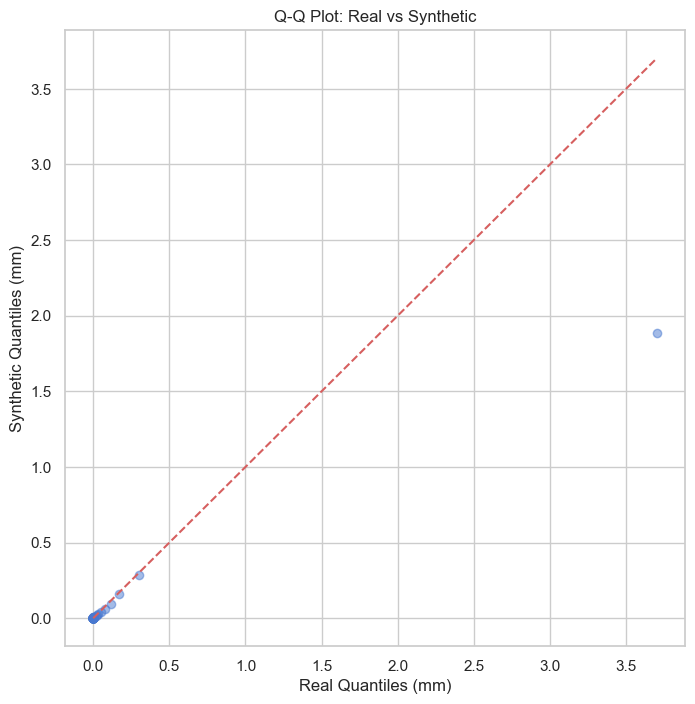

In [ ]:
summary = pd.DataFrame({
    'Real': df_real[col_real].describe(),
    'Synthetic': df_synth[col_synth].describe()
})

summary.loc['Wet %'] = [
    (df_real[col_real] > 0).mean() * 100,
    (df_synth[col_synth] > 0).mean() * 100
]

print("--- Statistical Summary ---")
display(summary)

# Visualizing Quantiles (Q-Q Plot logic)
plt.figure(figsize=(8, 8))
real_sorted = np.sort(df_real[col_real].sample(min(10000, len(df_real))))
synth_sorted = np.sort(df_synth[col_synth].sample(min(10000, len(df_synth))))
plt.scatter(np.percentile(real_sorted, np.linspace(0, 100, 100)),
            np.percentile(synth_sorted, np.linspace(0, 100, 100)), alpha=0.5)
plt.plot([0, max(real_sorted.max(), synth_sorted.max())], [0, max(real_sorted.max(), synth_sorted.max())], 'r--')
plt.xlabel('Real Quantiles (mm)')
plt.ylabel('Synthetic Quantiles (mm)')
plt.title('Q-Q Plot: Real vs Synthetic')
plt.show()

## 2. Intensity Spectrum (Wet-Step PDF)
Rainfall is highly skewed. We use log-scale to inspect the intensity distribution of wet steps.

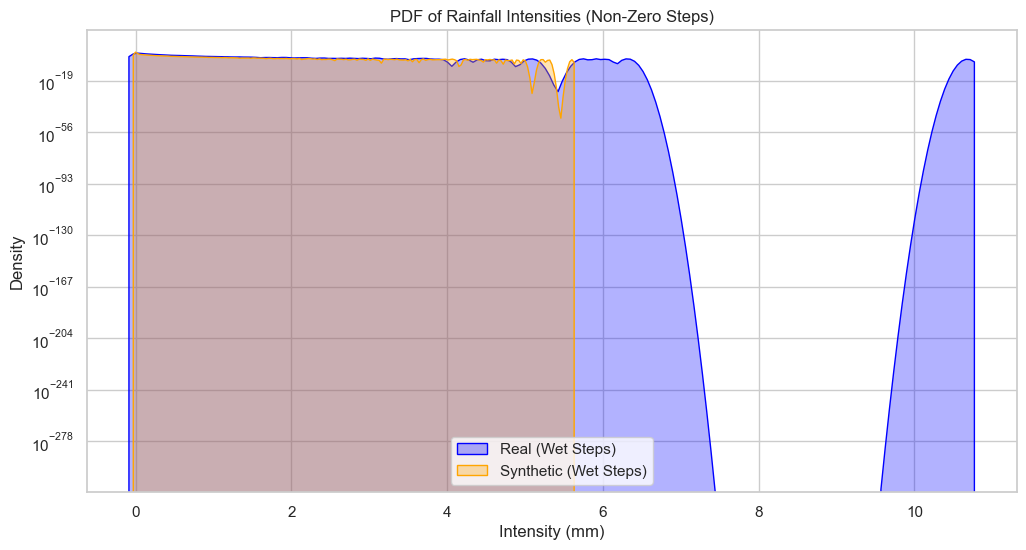

In [ ]:
wet_real = df_real[df_real[col_real] > 0][col_real]
wet_synth = df_synth[df_synth[col_synth] > 0][col_synth]

plt.figure(figsize=(12, 6))
sns.kdeplot(wet_real, label='Real (Wet Steps)', fill=True, color='blue', alpha=0.3)
sns.kdeplot(wet_synth, label='Synthetic (Wet Steps)', fill=True, color='orange', alpha=0.3)
plt.yscale('log')
plt.title('PDF of Rainfall Intensities (Non-Zero Steps)')
plt.xlabel('Intensity (mm)')
plt.legend()
plt.show()

## 3. Storm Dynamics (Duration & Persistence)
How long do storms last? This measures the model's ability to maintain temporal correlation.

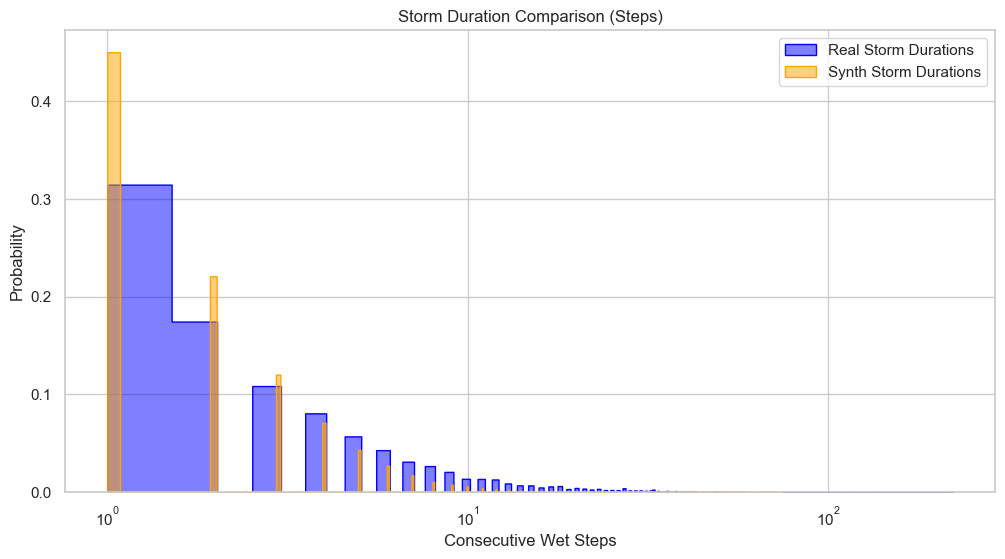

Mean Storm Duration (Real): 5.79 steps
Mean Storm Duration (Synth): 2.70 steps


In [ ]:
def get_storm_durations(series):
    is_wet = (series > 0).astype(int)
    group_id = (is_wet != is_wet.shift()).cumsum()
    return series[is_wet == 1].groupby(group_id).size()

dur_real = get_storm_durations(df_real[col_real])
dur_synth = get_storm_durations(df_synth[col_synth])

plt.figure(figsize=(12, 6))
sns.histplot(dur_real, label='Real Storm Durations', stat='probability', element='step', color='blue', alpha=0.5)
sns.histplot(dur_synth, label='Synth Storm Durations', stat='probability', element='step', color='orange', alpha=0.5)
plt.title('Storm Duration Comparison (Steps)')
plt.xlabel('Consecutive Wet Steps')
plt.xscale('log')
plt.legend()
plt.show()

print(f"Mean Storm Duration (Real): {dur_real.mean():.2f} steps")
print(f"Mean Storm Duration (Synth): {dur_synth.mean():.2f} steps")

## 4. Seasonal Consistency
Comparing monthly average rainfall totals.

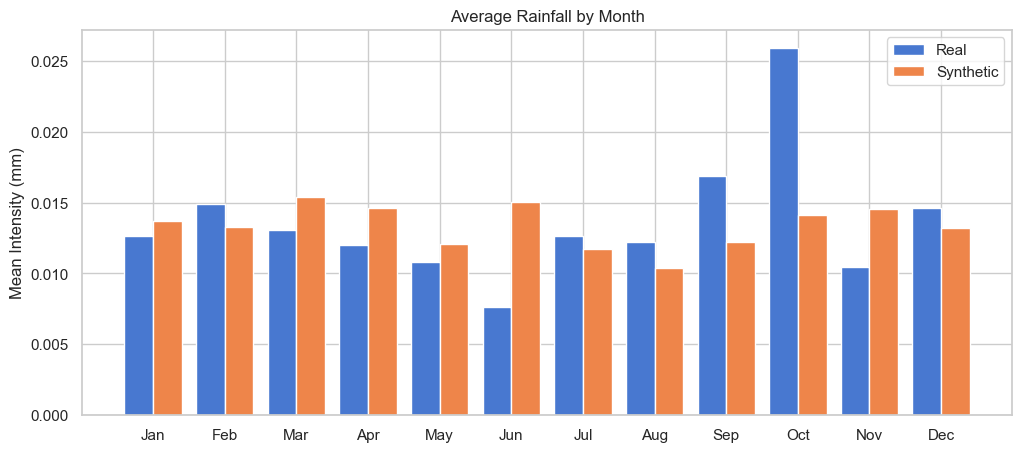

In [ ]:
monthly_real = df_real.groupby(df_real.index.month)[col_real].mean()
monthly_synth = df_synth.groupby(df_synth.index.month)[col_synth].mean()

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(12, 5))
x = np.arange(len(months))
plt.bar(x - 0.2, monthly_real, 0.4, label='Real')
plt.bar(x + 0.2, monthly_synth, 0.4, label='Synthetic')
plt.xticks(x, months)
plt.title('Average Rainfall by Month')
plt.ylabel('Mean Intensity (mm)')
plt.legend()
plt.show()

## 5. Persistence Analysis (Lag Correlation)
Autocorrelation function (ACF) comparison to check if short-term and long-term dependencies are captured.

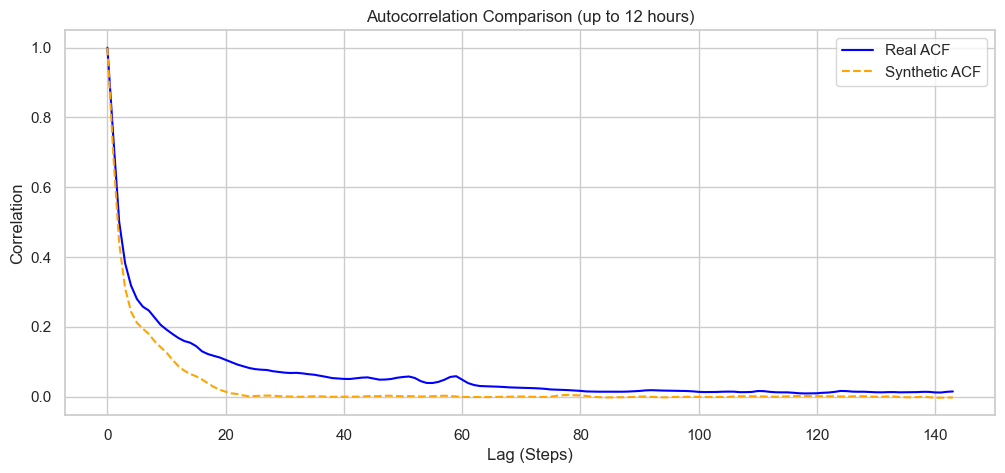

In [ ]:
def acf(series, lags):
    return [series.autocorr(lag=i) for i in range(lags)]

lags = 24 * 6 # 12 hours at 5min resolution
acf_real = acf(df_real[col_real], lags)
acf_synth = acf(df_synth[col_synth], lags)

plt.figure(figsize=(12, 5))
plt.plot(acf_real, label='Real ACF', color='blue')
plt.plot(acf_synth, label='Synthetic ACF', color='orange', linestyle='--')
plt.title('Autocorrelation Comparison (up to 12 hours)')
plt.xlabel('Lag (Steps)')
plt.ylabel('Correlation')
plt.legend()
plt.show()

## 6. Heavy Tail & Extremes
Return Levels: Percentage of total rainfall contributed by the top 1% of events.

In [ ]:
def extreme_contribution(series):
    top_1_pct = np.percentile(series, 99)
    total = series.sum()
    extreme_total = series[series >= top_1_pct].sum()
    return (extreme_total / total) * 100

ext_real = extreme_contribution(df_real[col_real])
ext_synth = extreme_contribution(df_synth[col_synth])

print(f"% Total Rainfall from Top 1% Events (Real): {ext_real:.2f}%")
print(f"% Total Rainfall from Top 1% Events (Synth): {ext_synth:.2f}%")

% Total Rainfall from Top 1% Events (Real): 48.06%
% Total Rainfall from Top 1% Events (Synth): 51.77%
